In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import umap
import pacmap

SEED = 42
np.random.seed(SEED)

In [2]:
# ── LOAD & PREPARE (mirrors sparsity_analysis.ipynb) ─────────────────────────
df = pd.read_csv('../data/MGKDB_unified_parameters_20260426_154819.csv')
param_cols = list(df.select_dtypes(include='number').columns)
df_params = df[param_cols].dropna()

scaler = MinMaxScaler()
X = scaler.fit_transform(df_params).astype(np.float32)

print(f"Shape: {X.shape}  ({X.shape[0]} samples × {X.shape[1]} dims)")
print(f"Parameters: {param_cols}")

Shape: (24563, 13)  (24563 samples × 13 dims)
Parameters: ['Beta', 'q', 'collisionality_elec', 's-hat', 'temp_grad_elec', 'temp_grad_ion', 'dens_grad_elec', 'dens_grad_ion', 'impurity_density', 'impurity_charge', 'alpha_MHD', 'Ti_over_Te', 'ky']


## 1. PCA — intrinsic dimensionality

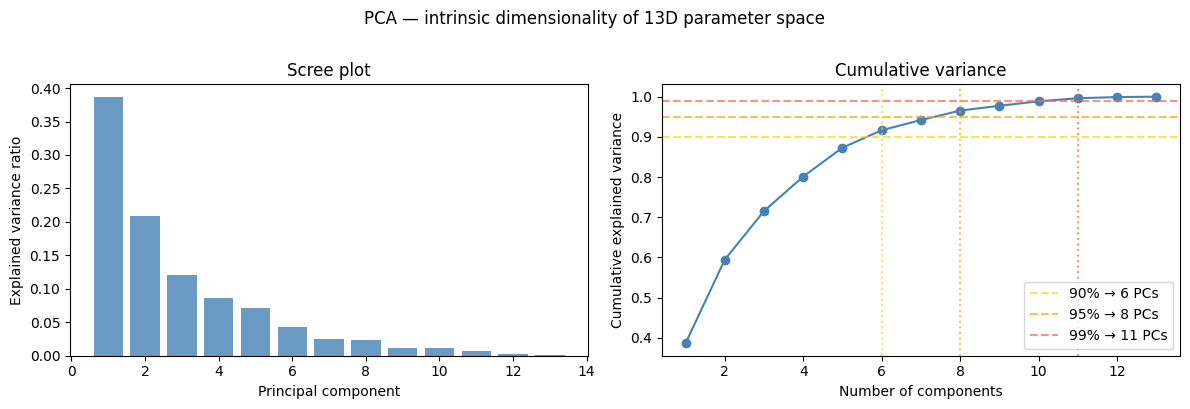

Dims needed: 90%=6, 95%=8, 99%=11


In [3]:
pca_full = PCA(random_state=SEED).fit(X)
ev = pca_full.explained_variance_ratio_
cumev = np.cumsum(ev)

n90 = np.searchsorted(cumev, 0.90) + 1
n95 = np.searchsorted(cumev, 0.95) + 1
n99 = np.searchsorted(cumev, 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(ev)+1), ev, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')

axes[1].plot(range(1, len(cumev)+1), cumev, marker='o', color='steelblue')
for thresh, n, col in [(0.90, n90, 'gold'), (0.95, n95, 'orange'), (0.99, n99, 'tomato')]:
    axes[1].axhline(thresh, color=col, linestyle='--', alpha=0.7, label=f'{int(thresh*100)}% → {n} PCs')
    axes[1].axvline(n, color=col, linestyle=':', alpha=0.7)
axes[1].set_xlabel('Number of components'); axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative variance'); axes[1].legend()

plt.suptitle('PCA — intrinsic dimensionality of 13D parameter space', y=1.01)
plt.tight_layout(); plt.show()
print(f"Dims needed: 90%={n90}, 95%={n95}, 99%={n99}")

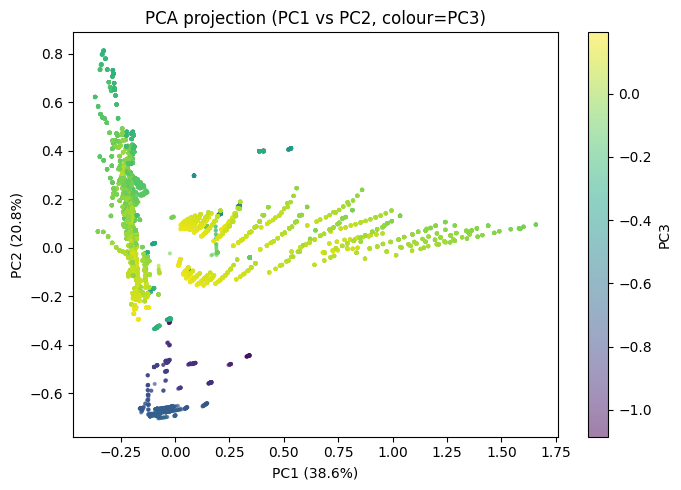

In [4]:
# PCA 2D scatter (PC1 vs PC2, coloured by PC3)
pca2 = PCA(n_components=3, random_state=SEED)
Z_pca = pca2.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1], c=Z_pca[:, 2],
                cmap='viridis', s=4, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label='PC3')
ax.set_xlabel(f'PC1 ({ev[0]:.1%})')
ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
ax.set_title('PCA projection (PC1 vs PC2, colour=PC3)')
plt.tight_layout(); plt.show()

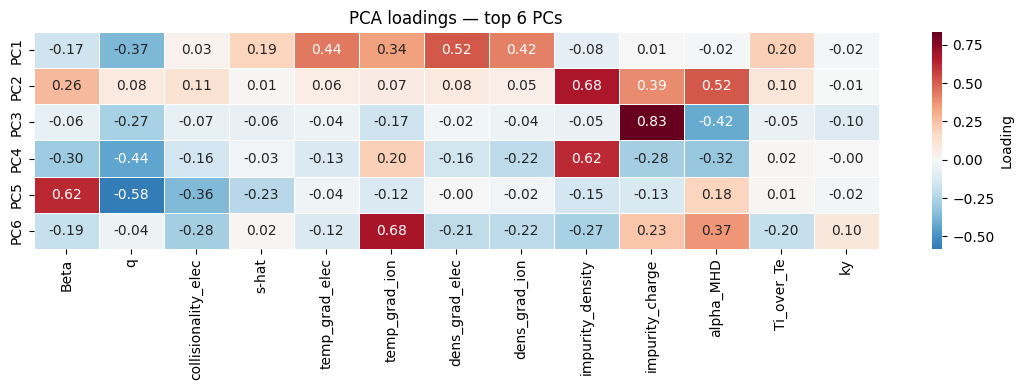

In [5]:
# PCA loadings heatmap
loadings = pd.DataFrame(
    pca_full.components_[:6],
    index=[f'PC{i+1}' for i in range(6)],
    columns=param_cols
)
fig, ax = plt.subplots(figsize=(len(param_cols)*0.7+2, 4))
sns.heatmap(loadings, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.4,
            cbar_kws={'label': 'Loading'})
ax.set_title('PCA loadings — top 6 PCs')
plt.tight_layout(); plt.show()

## 2. UMAP — 6 hyperparameter configurations

In [6]:
umap_configs = [
    dict(n_neighbors=5,   min_dist=0.05, label='n_neighbors=5,  min_dist=0.05  (tight local)'),
    dict(n_neighbors=15,  min_dist=0.1,  label='n_neighbors=15, min_dist=0.1   (default-ish)'),
    dict(n_neighbors=30,  min_dist=0.1,  label='n_neighbors=30, min_dist=0.1   (broader local)'),
    dict(n_neighbors=50,  min_dist=0.3,  label='n_neighbors=50, min_dist=0.3   (global structure)'),
    dict(n_neighbors=15,  min_dist=0.5,  label='n_neighbors=15, min_dist=0.5   (spread clusters)'),
    dict(n_neighbors=100, min_dist=0.0,  label='n_neighbors=100,min_dist=0.0   (max compression)'),
]

umap_embeddings = []
for cfg in umap_configs:
    label = cfg.pop('label')
    emb = umap.UMAP(n_components=2, random_state=SEED, **cfg).fit_transform(X)
    umap_embeddings.append((label, emb))
    cfg['label'] = label  # restore
    print(f'Done: {label}')

/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eig

Done: n_neighbors=5,  min_dist=0.05  (tight local)


/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done: n_neighbors=15, min_dist=0.1   (default-ish)


/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

Done: n_neighbors=50, min_dist=0.3   (global structure)


/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done: n_neighbors=15, min_dist=0.5   (spread clusters)


/global/homes/j/joeschm/.conda/envs/data_analysis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done: n_neighbors=100,min_dist=0.0   (max compression)


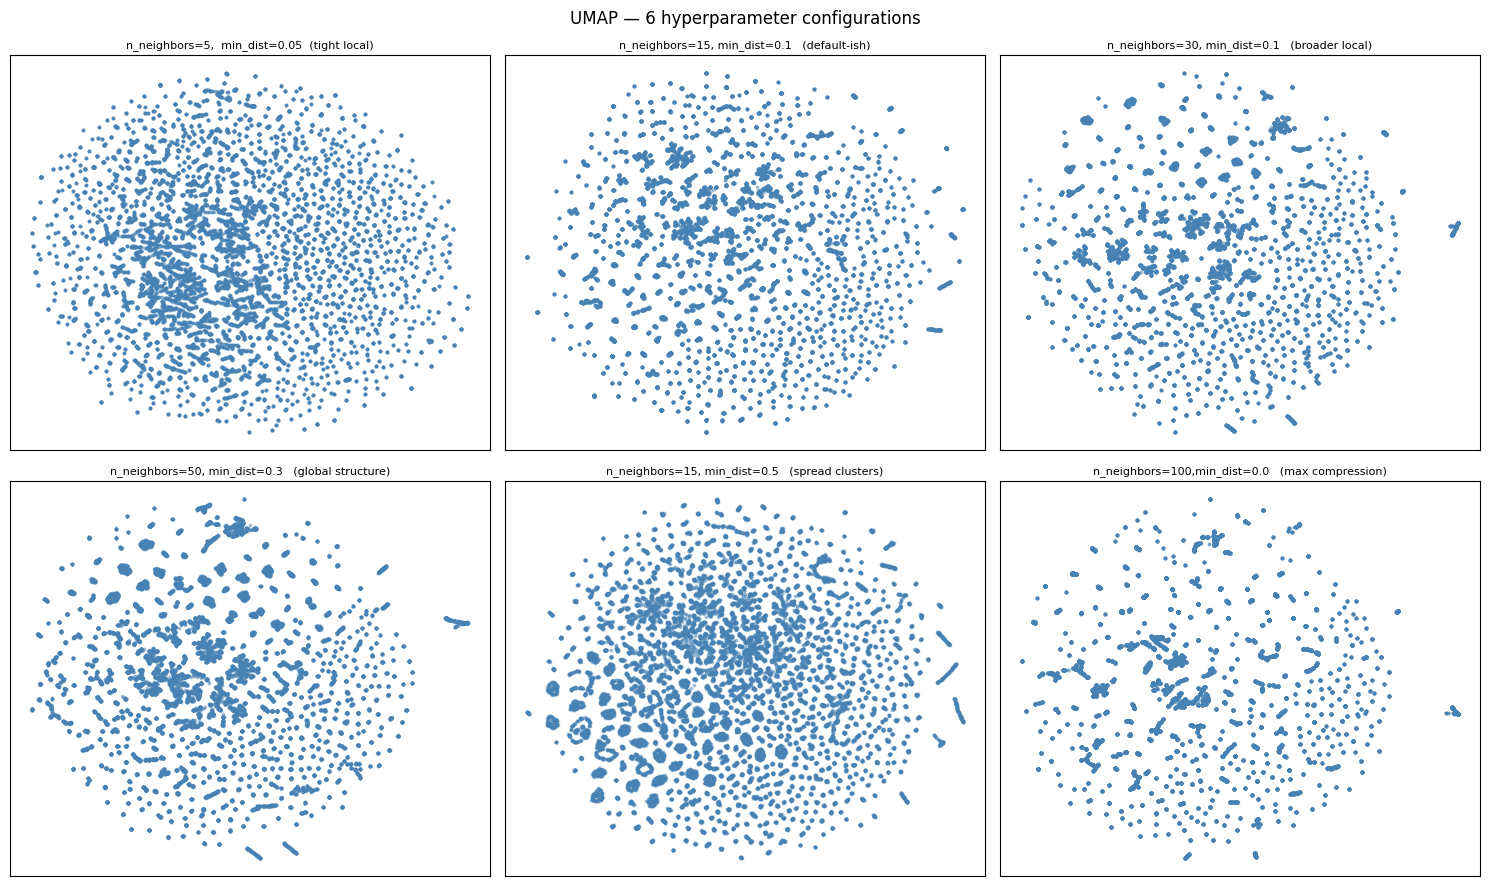

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, emb) in zip(axes.flat, umap_embeddings):
    ax.scatter(emb[:, 0], emb[:, 1], s=3, alpha=0.4, rasterized=True, color='steelblue')
    ax.set_title(label, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('UMAP — 6 hyperparameter configurations', fontsize=12)
plt.tight_layout(); plt.show()

## 3. PaCMAP — 6 hyperparameter configurations

In [8]:
pacmap_configs = [
    dict(n_neighbors=10, MN_ratio=0.5,  FP_ratio=2.0,  label='nn=10, MN=0.5, FP=2.0  (default-ish)'),
    dict(n_neighbors=5,  MN_ratio=0.5,  FP_ratio=2.0,  label='nn=5,  MN=0.5, FP=2.0  (tight local)'),
    dict(n_neighbors=30, MN_ratio=0.5,  FP_ratio=2.0,  label='nn=30, MN=0.5, FP=2.0  (broad local)'),
    dict(n_neighbors=10, MN_ratio=2.0,  FP_ratio=2.0,  label='nn=10, MN=2.0, FP=2.0  (mid-range pull)'),
    dict(n_neighbors=10, MN_ratio=0.1,  FP_ratio=5.0,  label='nn=10, MN=0.1, FP=5.0  (strong repulsion)'),
    dict(n_neighbors=20, MN_ratio=1.0,  FP_ratio=1.0,  label='nn=20, MN=1.0, FP=1.0  (balanced)'),
]

pacmap_embeddings = []
for cfg in pacmap_configs:
    label = cfg.pop('label')
    emb = pacmap.PaCMAP(n_components=2, random_state=SEED, **cfg).fit_transform(X)
    pacmap_embeddings.append((label, emb))
    cfg['label'] = label
    print(f'Done: {label}')

Done: nn=10, MN=0.5, FP=2.0  (default-ish)


Done: nn=5,  MN=0.5, FP=2.0  (tight local)


Done: nn=30, MN=0.5, FP=2.0  (broad local)


Done: nn=10, MN=2.0, FP=2.0  (mid-range pull)


Done: nn=10, MN=0.1, FP=5.0  (strong repulsion)
Done: nn=20, MN=1.0, FP=1.0  (balanced)


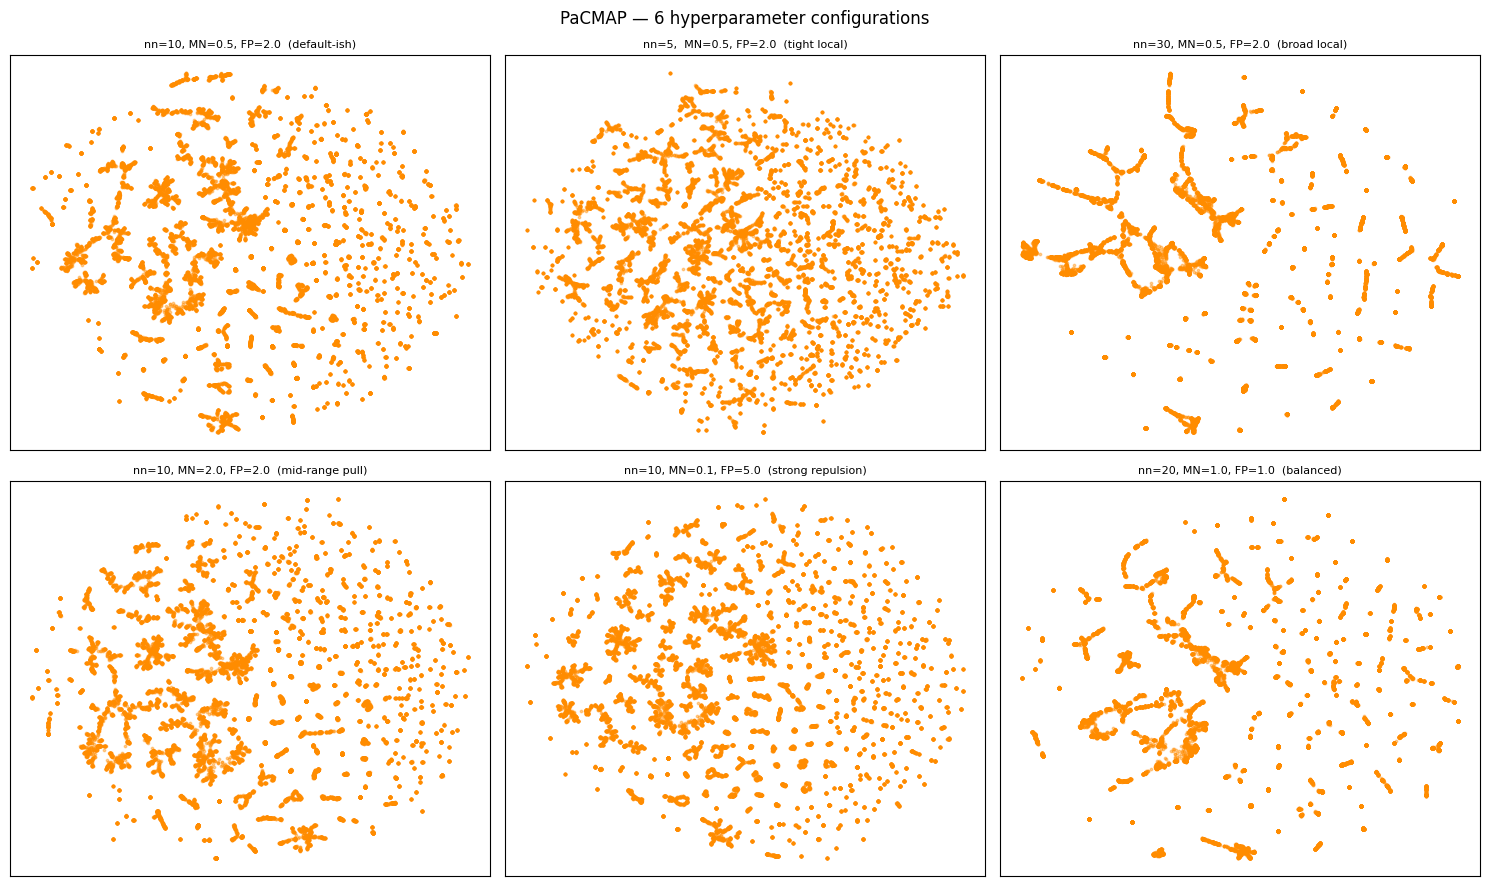

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, emb) in zip(axes.flat, pacmap_embeddings):
    ax.scatter(emb[:, 0], emb[:, 1], s=3, alpha=0.4, rasterized=True, color='darkorange')
    ax.set_title(label, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('PaCMAP — 6 hyperparameter configurations', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Side-by-side comparison: best UMAP vs best PaCMAP vs PCA

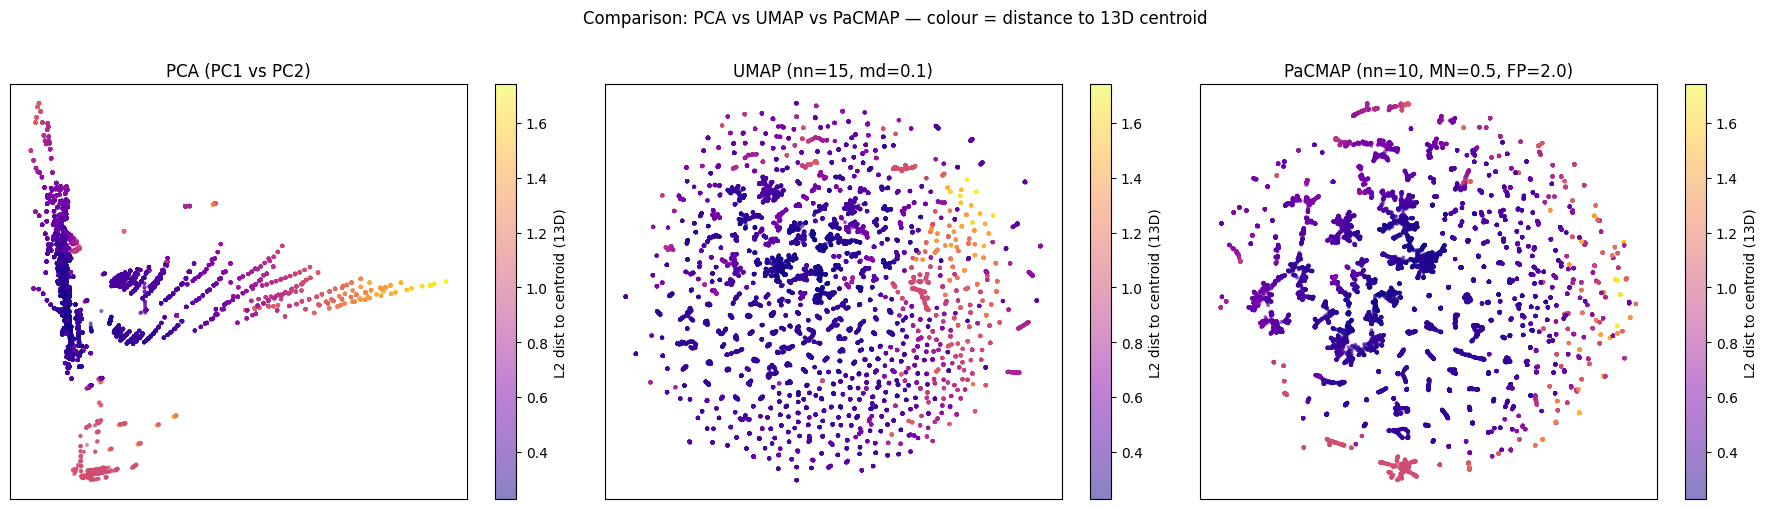

In [10]:
# Colour points by their distance to the global centroid in original 13D space
# (proxy for how 'extreme' a point is — useful for seeing if outliers cluster)
centroid = X.mean(axis=0)
dist_to_center = np.linalg.norm(X - centroid, axis=1)

# Pick one representative from each method (n_neighbors=15, min_dist=0.1 for UMAP;
# nn=10 default for PaCMAP)
umap_best  = umap_embeddings[1][1]   # index 1 = n_neighbors=15, min_dist=0.1
pacmap_best = pacmap_embeddings[0][1] # index 0 = default-ish

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['PCA (PC1 vs PC2)', 'UMAP (nn=15, md=0.1)', 'PaCMAP (nn=10, MN=0.5, FP=2.0)']
embeds = [Z_pca[:, :2], umap_best, pacmap_best]

for ax, title, emb in zip(axes, titles, embeds):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=dist_to_center,
                    cmap='plasma', s=4, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label='L2 dist to centroid (13D)')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Comparison: PCA vs UMAP vs PaCMAP — colour = distance to 13D centroid', y=1.01)
plt.tight_layout(); plt.show()

## 5. Pairwise correlation & redundancy in original 13D space

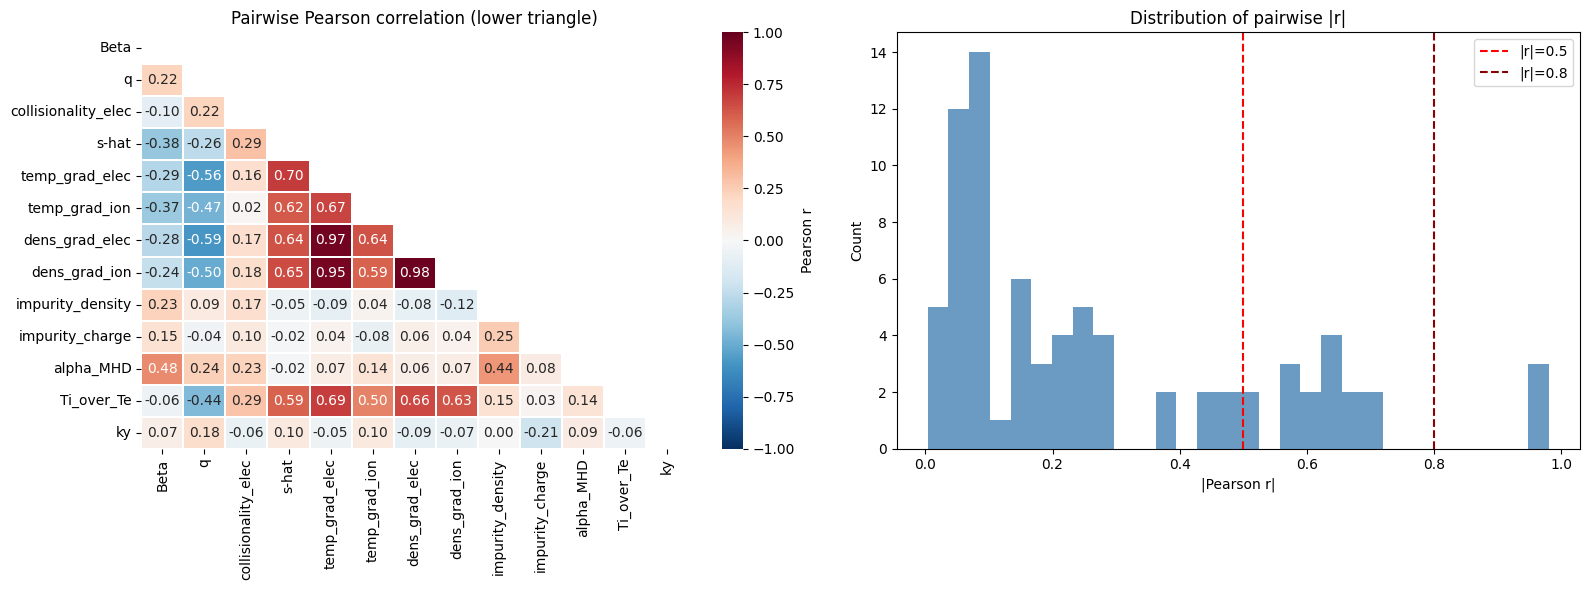

Pairs with |r| > 0.8: 3 / 78


In [11]:
corr = df_params.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Pairwise Pearson correlation (lower triangle)')

# Distribution of |r| values (excluding diagonal)
r_vals = corr.values[np.tril_indices_from(corr.values, k=-1)]
axes[1].hist(np.abs(r_vals), bins=30, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0.5, color='red', linestyle='--', label='|r|=0.5')
axes[1].axvline(0.8, color='darkred', linestyle='--', label='|r|=0.8')
axes[1].set_xlabel('|Pearson r|'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of pairwise |r|')
axes[1].legend()

plt.tight_layout(); plt.show()

n_high = (np.abs(r_vals) > 0.8).sum()
print(f"Pairs with |r| > 0.8: {n_high} / {len(r_vals)}")

## 6. Effective dimensionality summary

In [12]:
# Participation ratio — measures effective number of PCA dimensions used
# PR = (sum λ_i)^2 / sum(λ_i^2)  where λ_i are eigenvalues
eigvals = pca_full.explained_variance_
PR = eigvals.sum()**2 / (eigvals**2).sum()

print("── Effective dimensionality summary ──")
print(f"  Total dims:              {X.shape[1]}")
print(f"  Participation ratio:     {PR:.2f}  (effective dims by eigenvalue spread)")
print(f"  Dims for 90% variance:   {n90}")
print(f"  Dims for 95% variance:   {n95}")
print(f"  Dims for 99% variance:   {n99}")
print()
print("Per-PC explained variance:")
for i, (e, c) in enumerate(zip(ev, cumev)):
    print(f"  PC{i+1:2d}: {e:.3%}  (cumulative {c:.3%})")

── Effective dimensionality summary ──
  Total dims:              13
  Participation ratio:     4.48  (effective dims by eigenvalue spread)
  Dims for 90% variance:   6
  Dims for 95% variance:   8
  Dims for 99% variance:   11

Per-PC explained variance:
  PC 1: 38.626%  (cumulative 38.626%)
  PC 2: 20.809%  (cumulative 59.435%)
  PC 3: 12.104%  (cumulative 71.539%)
  PC 4: 8.589%  (cumulative 80.128%)
  PC 5: 7.183%  (cumulative 87.311%)
  PC 6: 4.346%  (cumulative 91.657%)
  PC 7: 2.534%  (cumulative 94.191%)
  PC 8: 2.345%  (cumulative 96.536%)
  PC 9: 1.203%  (cumulative 97.738%)
  PC10: 1.110%  (cumulative 98.848%)
  PC11: 0.767%  (cumulative 99.615%)
  PC12: 0.284%  (cumulative 99.899%)
  PC13: 0.101%  (cumulative 100.000%)
